#### Homogeneous Laplace equation

In [1]:
r, eta = var('r, eta');theta = function('theta');
assume(r>=0)
assume(eta <= 1);assume(eta >= -1);

NameError: name 'var' is not defined

In [2]:
def laplaceEq(u):
    return (1/r^2)*diff((r^2)*diff(u,r),r)==-(1/r^2)*diff((1-eta^2)*diff(u,eta),eta);

In [4]:
show(laplaceEq(theta(r,eta)))

(r^2*diff(theta(r, eta), r, r) + 2*r*diff(theta(r, eta), r))/r^2 == (2*eta*diff(theta(r, eta), eta) + (eta^2 - 1)*diff(theta(r, eta), eta, eta))/r^2

In [5]:
f = function('f'); g = function('g');
show(laplaceEq(f(r)*g(eta)))

(r^2*g(eta)*diff(f(r), r, r) + 2*r*g(eta)*diff(f(r), r))/r^2 == (2*eta*f(r)*diff(g(eta), eta) + (eta^2 - 1)*f(r)*diff(g(eta), eta, eta))/r^2

In [6]:
l = var('l')
assume(l, 'integer');
assume(l >= 0)
eqnf=((laplaceEq(f(r)*g(eta))/(f(r)*g(eta)/(r^2))).simplify_full()).lhs()==l*(l+1)
eqng=((laplaceEq(f(r)*g(eta))/(f(r)*g(eta)/(r^2))).simplify_full()).rhs()==l*(l+1)
show(eqnf)
show(eqng)

(r^2*diff(f(r), r, r) + 2*r*diff(f(r), r))/f(r) == (l + 1)*l

(2*eta*diff(g(eta), eta) + (eta^2 - 1)*diff(g(eta), eta, eta))/g(eta) == (l + 1)*l

In [8]:
fsol=desolve(eqnf,[f(r),r])

In [9]:
show(fsol.simplify())

_K1*r^(1/2*sqrt(4*l^2 + 4*l + 1) - 1/2) + _K2*r^(-1/2*sqrt(4*l^2 + 4*l + 1) - 1/2)

In [10]:
fsol=fsol.subs(sqrt(4*l^2+4*l+1) == (2*l+1)).simplify()
show(fsol)

_K1*r^l + _K2*r^(-l - 1)

In [11]:
eqng_full=-(eqng*g(eta)).lhs()+(eqng*g(eta)).rhs()==0
show(eqng_full)

(l + 1)*l*g(eta) - 2*eta*diff(g(eta), eta) - (eta^2 - 1)*diff(g(eta), eta, eta) == 0

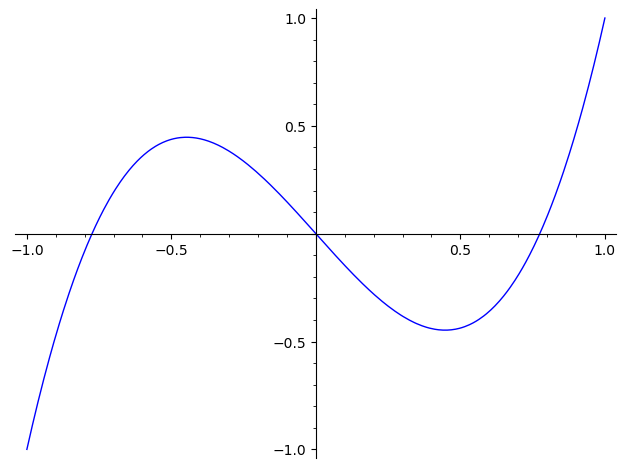

In [221]:
Pl = legendre_P(l, eta);
plot(Pl.subs(l=3),(eta,-1,1))

In [54]:
eqnglhs=eqng_full.lhs()
eqnglhs

(l + 1)*l*g(eta) - 2*eta*diff(g(eta), eta) - (eta^2 - 1)*diff(g(eta), eta, eta)

In [55]:
Pl(eta) = legendre_P(l, eta);
diff(Pl(eta),eta)

(eta*l*legendre_P(l, eta) - l*legendre_P(l - 1, eta))/(eta^2 - 1)

In [69]:
eqngRes=eqng_full.substitute_function(g,Pl)
eqngRes

(l + 1)*l*legendre_P(l, eta) - (eta^2 - 1)*(((eta*l*legendre_P(l, eta) - l*legendre_P(l - 1, eta))*eta*l/(eta^2 - 1) + l*legendre_P(l, eta) - (eta*(l - 1)*legendre_P(l - 1, eta) - (l - 1)*legendre_P(l - 2, eta))*l/(eta^2 - 1))/(eta^2 - 1) - 2*(eta*l*legendre_P(l, eta) - l*legendre_P(l - 1, eta))*eta/(eta^2 - 1)^2) - 2*(eta*l*legendre_P(l, eta) - l*legendre_P(l - 1, eta))*eta/(eta^2 - 1) == 0

In [105]:
[eqngRes.subs(l=lval).simplify_full() for lval in srange(0,4,1)]

[0 == 0, 0 == 0, 0 == 0, 0 == 0]

In [115]:
#General homogeneous solution
homosol=fsol*Pl
show(homosol)

(_K1*r^l + _K2*r^(-l - 1))*legendre_P(l, eta)

#### Leading order (inner) conduction solution

In [116]:
theta0_sol=(homosol).subs(l=0).subs(_K1=0,_K2=1)
theta0_sol

1/r

In [117]:
x, y = var('x, y');
theta0_cart=theta0_sol.subs({r:sqrt(x^2+y^2),eta: x/sqrt(x^2+y^2)})
theta0_cart

1/sqrt(x^2 + y^2)

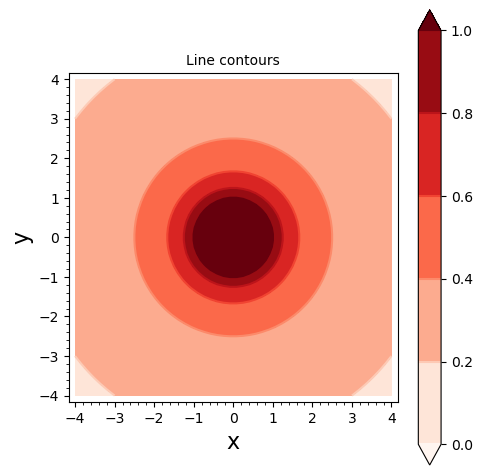

In [118]:
p = contour_plot(
    theta0_cart, (x, -4, 4), (y, -4, 4),
    contours=[0,0.2,0.4,0.6,0.8,1],   # pick your levels
    fill=True,                          # filled contours; omit for lines
    plot_points=50,
    cmap='Reds',
    colorbar=True
)
p.show(figsize=(5, 5), aspect_ratio=1, axes_labels=['x','y'], title='Line contours')

#### Trying regular perturbation first order solution

In [125]:
#In general, one has to project the eta-dependence of the RHS onto the basis set of orthogonal legendre polynomials
show(Matrix([[integrate(Pl.subs(l=l1)*Pl.subs(l=l2),(eta,-1,1)) for l1 in srange(0,4,1)] for l2 in srange(0,4,1)]))

[  2   0   0   0]
[  0 2/3   0   0]
[  0   0 2/5   0]
[  0   0   0 2/7]

In [140]:
#But we just have P1 on the RHS.
m, A = var('m','A')
guess_particular=A*(r^m)*Pl.subs(l=1)
show(guess_particular)
partform=((laplaceEq(guess_particular).lhs()-laplaceEq(guess_particular).rhs())/Pl.subs(l=1)).simplify_full()
show(partform)

A*eta*r^m

(A*m^2 + A*m - 2*A)*r^(m - 2)

In [195]:
RHS=(-1/r^2, +3/(2*r^3),-1/(2*r^5))
partcoeff=vector(SR, len(RHS))
partexponent=vector(SR, len(RHS))
partform

(A*m^2 + A*m - 2*A)*r^(m - 2)

In [196]:
#Forming a particular solution to account for each term on the RHS
from sage.symbolic.ring import SR
k    = SR.wild(0)   # wildcard for the exponent
rest = SR.wild(1)   # wildcard for "the rest" of the product

split=partform.match(r^k * rest)   # try to match expr to r^k * (something)
splitRHS=RHS[1].match(r^k * rest)
show(split[k]==splitRHS[k])
show(split[rest]==splitRHS[rest])

m - 2 == -3

A*m^2 + A*m - 2*A == (3/2)

In [197]:
solm=solve(split[k]==splitRHS[k],m)
solA=solve((split[rest]==splitRHS[rest]).subs(solm),A)
(A*(r^m)).subs(solm,solA)

-3/4/r

In [205]:
for i in range(0,len(RHS)):
    splitRHS=RHS[i].match(r^k * rest)
    solm=solve(split[k]==splitRHS[k],m)
    solA=solve((split[rest]==splitRHS[rest]).subs(solm),A)
    partcoeff[i]=(A).subs(solA)
    partexponent[i]=(m).subs(solm)

In [219]:
partsol=sum([partcoeff[i]*r^partexponent[i] for i in srange(0,len(RHS))])
show(homosol+ (partsol)*Pl.subs(l=1))

-1/8*eta*(6/r + 1/r^3 - 4) + (_K1*r^l + _K2*r^(-l - 1))*legendre_P(l, eta)

##### Clearly the $r$-independent term does not allow us to satisfy the BC at $\infty$ and so a regular perturbation solution is not possible.
##### The theta0 solution is just the leading-order inner solution
##### We now have to find the leading order outer solution

#### Outer solution